https://wandb.ai/dstech/drop-wall-impact-clfr/table?workspace=user-dimazharikov10

Лучшими моделями по сочетанию F1/ROC-AUC являются:

* splashing
    1) featurewiz + CatBoost + SMOTENC
    2) featurewiz + CatBoost + SMOTENC + optuna, no strange columns
* net_impact
    1) featurewiz + CatBoost + SMOTENC + optuna, net_impact, no strange columns

Проверим, как показывают себя модели, если убрать из обучающей и тестовой выборок дубликаты.

# Загрузка библиотек

In [1]:
import pandas as pd
import sys
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

In [2]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *
from models.class_models import *
from models.hyperparams_tuning import *
from models.blending import *

Imported 0.2.6 version. Select nrows to a small number when running on huge datasets.
output = featurewiz(dataname, target, corr_limit=0.90, verbose=2, sep=',', 
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False)
Create new features via 'feature_engg' flag : ['interactions','groupby','target']



In [ ]:
import wandb
wandb.login(key='8b1f2ae49570ea59dc8612ff434ca497d463d221')

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [6]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
stranger_things = ['voltage', 'long_impulse_duration', 'long_impulse_dur_binary']
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# splashing

## featurewiz + CatBoost + SMOTENC

In [7]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True, drop_duplicates=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [10]:
df.shape, X_train.shape[0] + X_test.shape[0]

((372, 28), 357)

In [13]:
smote_nc = SMOTENC(categorical_features=[9], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC, splashing, no duplicates'
)

In [15]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.848485,0.875000,0.861538,64.00000
1,0.854545,0.824561,0.839286,57.00000
accuracy,0.851240,0.851240,0.851240,0.85124
macro avg,0.851515,0.849781,0.850412,121.00000
weighted avg,0.851340,0.851240,0.851056,121.00000


#### Cross-Validation

In [18]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.44% (std: 2.39%)
F1 Test:	80.52% (std: 11.37%)


#### SHAP interpretation

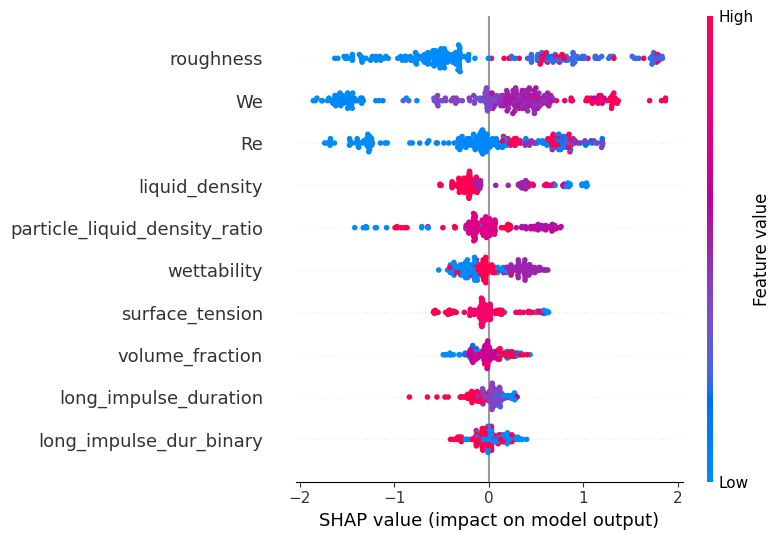

In [17]:
get_shap_interpretation(model, X_train)

## featurewiz + CatBoost + SMOTENC + optuna, no strange columns

In [20]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True, drop_duplicates=True, strange_columns=stranger_things)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [21]:
df.shape, X_train.shape[0] + X_test.shape[0]

((372, 28), 349)

In [24]:
smote_nc = SMOTENC(categorical_features=[6], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, splashing, no strange columns, no duplicates'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=70, timeout=None)

In [27]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/splashing')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.865672,0.906250,0.885496,64.000
1,0.886792,0.839286,0.862385,56.000
accuracy,0.875000,0.875000,0.875000,0.875
macro avg,0.876232,0.872768,0.873941,120.000
weighted avg,0.875528,0.875000,0.874711,120.000


# net_impact

## featurewiz + CatBoost + SMOTENC + optuna, net_impact, no strange columns

In [32]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True, drop_duplicates=True, strange_columns=stranger_things)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [33]:
df.shape, X_train.shape[0] + X_test.shape[0]

((372, 28), 99)

In [38]:
smote_nc = SMOTENC(categorical_features=[5], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, net_impact, no strange columns, no duplicates'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=70, timeout=None)

In [41]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.906250,0.828571,0.865672,35.000000
1,0.600000,0.750000,0.666667,12.000000
accuracy,0.808511,0.808511,0.808511,0.808511
macro avg,0.753125,0.789286,0.766169,47.000000
weighted avg,0.828059,0.808511,0.814862,47.000000


#### Cross-Validation

In [42]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	79.93% (std: 8.93%)
F1 Test:	49.43% (std: 32.09%)


#### SHAP interpretation

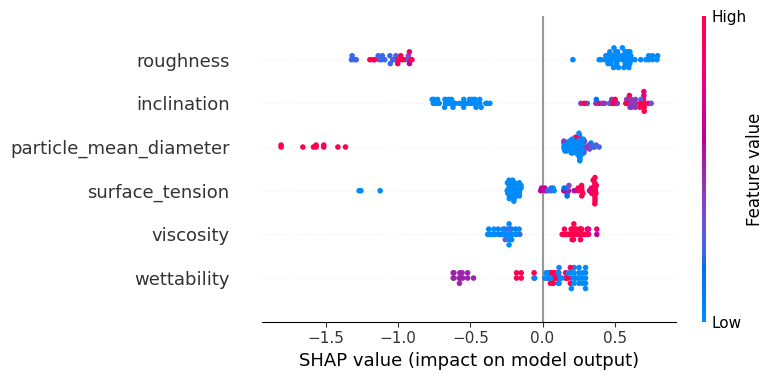

In [43]:
get_shap_interpretation(model, X_train)